In [33]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader
import ast
import time
import random

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

set_seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device

device(type='cuda')

In [34]:
df_seq = pd.read_csv('input/user_behavior.csv')

if isinstance(df_seq['posts_sequence'].iloc[0], str):
    df_seq['posts_sequence_list'] = df_seq['posts_sequence'].apply(ast.literal_eval)
else:
    df_seq['posts_sequence_list'] = df_seq['posts_sequence']

all_post_ids = set()
for seq in df_seq['posts_sequence_list']:
    all_post_ids.update(seq)

sorted_ids = sorted(list(all_post_ids))
post2idx = {pid: i+1 for i, pid in enumerate(sorted_ids)}
idx2post = {i+1: pid for i, pid in enumerate(sorted_ids)}
VOCAB_SIZE = len(post2idx) + 1

print(f"Vocab Size: {VOCAB_SIZE}")

Vocab Size: 530


In [35]:
train_samples = []
test_samples = []

for idx, row in df_seq.iterrows():
    raw_seq = row['posts_sequence_list']
    seq = [post2idx.get(pid, 0) for pid in raw_seq]
    
    if len(seq) < 2: continue
    test_samples.append((seq[:-1], seq[-1]))
    train_seq_full = seq[:-1]
    
    for i in range(1, len(train_seq_full)):
        start_idx = max(0, i - 20) 
        tr_input = train_seq_full[start_idx:i]
        tr_target = train_seq_full[i]
        train_samples.append((tr_input, tr_target))

print(f"Train Samples: {len(train_samples)}")
print(f"Test Samples: {len(test_samples)}")

Train Samples: 658
Test Samples: 231


In [36]:
class InteractionDataset(Dataset):
    def __init__(self, samples):
        self.samples = samples
    
    def __len__(self):
        return len(self.samples)
    
    def __getitem__(self, idx):
        input_seq, target = self.samples[idx]
        return torch.tensor(input_seq, dtype=torch.long), torch.tensor(target, dtype=torch.long)

def collate_fn(batch):
    inputs, targets = zip(*batch)
    inputs_padded = torch.nn.utils.rnn.pad_sequence(inputs, batch_first=True, padding_value=0)
    return inputs_padded, torch.stack(targets)

BATCH_SIZE = 32
train_loader = DataLoader(InteractionDataset(train_samples), batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_fn)
test_loader = DataLoader(InteractionDataset(test_samples), batch_size=BATCH_SIZE, collate_fn=collate_fn)

In [37]:
class DeepBiLSTM(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_dim, num_layers, dropout):
        super(DeepBiLSTM, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=0)
        self.lstm = nn.LSTM(embedding_dim, hidden_dim, num_layers, batch_first=True, 
                           bidirectional=True, dropout=dropout)
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_dim * 2, vocab_size)
        
    def forward(self, x):
        embedded = self.embedding(x)
        # lstm_out: [Batch, Seq, Hidden*2]
        lstm_out, _ = self.lstm(embedded)
        out = torch.mean(lstm_out, dim=1)
        
        out = self.dropout(out)
        return self.fc(out)

In [38]:
class BiLSTM_SelfAttention(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_dim, num_layers, dropout):
        super(BiLSTM_SelfAttention, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=0)
        self.lstm = nn.LSTM(embedding_dim, hidden_dim, num_layers, batch_first=True,
                           bidirectional=True, dropout=dropout)
        
        # Attention Weights:
        self.attn_fc = nn.Linear(hidden_dim * 2, 1)
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_dim * 2, vocab_size)
        
    def forward(self, x):
        embedded = self.embedding(x)
        lstm_out, _ = self.lstm(embedded) # [Batch, Seq, Hidden*2]
        
        # Attention Score
        attn_scores = self.attn_fc(lstm_out) # [Batch, Seq, 1]
        attn_weights = torch.softmax(attn_scores, dim=1)
        
        # Weighted Sum
        context = torch.sum(attn_weights * lstm_out, dim=1) # [Batch, Hidden*2]
        
        out = self.dropout(context)
        return self.fc(out)

In [39]:
class BiLSTM_MHA(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_dim, num_layers, num_heads, dropout):
        super(BiLSTM_MHA, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=0)
        self.lstm = nn.LSTM(embedding_dim, hidden_dim, num_layers, batch_first=True,
                           bidirectional=True, dropout=dropout)
        
        # MHA
        self.mha = nn.MultiheadAttention(embed_dim=hidden_dim*2, num_heads=num_heads, 
                                         dropout=dropout, batch_first=True)
        self.norm = nn.LayerNorm(hidden_dim*2) 
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_dim * 2, vocab_size)
        
    def forward(self, x):
        embedded = self.embedding(x)
        lstm_out, _ = self.lstm(embedded)
        
        # Self-Attention: Q=K=V=lstm_out
        attn_out, _ = self.mha(lstm_out, lstm_out, lstm_out)
        
        # Skip connection + Norm
        out = self.norm(attn_out + lstm_out)
        
        # Mean Pooling
        context = torch.mean(out, dim=1)
        
        out = self.dropout(context)
        return self.fc(out)

In [40]:
def train_model(model, train_loader, epochs=30, lr=0.0005, name="Model"):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)
    criterion = nn.CrossEntropyLoss()
    model.train()
    
    print(f"🚀 Training {name}...")
    for epoch in range(epochs):
        total_loss = 0
        for inputs, targets in train_loader:
            inputs, targets = inputs.to(device), targets.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, targets)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
            
        if (epoch+1) % 10 == 0:
            print(f"   Epoch {epoch+1} | Loss: {total_loss/len(train_loader):.4f}")
    return model

def evaluate(model, test_loader, k_list=[5, 10]):
    model.eval()
    hits = {k: 0 for k in k_list}
    mrr_sum = 0
    total = 0
    
    with torch.no_grad():
        for inputs, targets in test_loader:
            inputs, targets = inputs.to(device), targets.to(device)
            outputs = model(inputs) # [Batch, Vocab]
            
            # Top-20 
            _, topk = torch.topk(outputs, 20, dim=1)
            topk = topk.cpu().numpy()
            
            for i, target in enumerate(targets):
                true_id = target.item()
                pred_ids = topk[i]
                
                # Hit Rate
                for k in k_list:
                    if true_id in pred_ids[:k]:
                        hits[k] += 1
                
                # MRR
                if true_id in pred_ids:
                    rank = np.where(pred_ids == true_id)[0][0] + 1
                    mrr_sum += 1.0 / rank
                
                total += 1
                
    return {f'HR@{k}': v/total for k, v in hits.items()}, mrr_sum/total

In [44]:
EMBED_DIM = 128
HIDDEN_DIM = 128
LAYERS = 1    
DROPOUT = 0.5
HEADS = 2
EPOCHS = 70

results = {}
# 1. BiLSTM
model1 = DeepBiLSTM(VOCAB_SIZE, EMBED_DIM, HIDDEN_DIM, LAYERS, DROPOUT).to(device)
train_model(model1, train_loader, epochs=EPOCHS, name="Deep BiLSTM")
hr1, mrr1 = evaluate(model1, test_loader)
results['Deep BiLSTM'] = {**hr1, 'MRR': mrr1}

# 2. Bilstm + Self-Attention
model2 = BiLSTM_SelfAttention(VOCAB_SIZE, EMBED_DIM, HIDDEN_DIM, LAYERS, DROPOUT).to(device)
train_model(model2, train_loader, epochs=EPOCHS, name="Self-Attention")
hr2, mrr2 = evaluate(model2, test_loader)
results['Self-Attention'] = {**hr2, 'MRR': mrr2}

# 3. Bilstm + Multi-Head Attention
model3 = BiLSTM_MHA(VOCAB_SIZE, EMBED_DIM, HIDDEN_DIM, LAYERS, HEADS, DROPOUT).to(device)
train_model(model3, train_loader, epochs=EPOCHS, name="Multi-Head Attention")
hr3, mrr3 = evaluate(model3, test_loader)
results['Multi-Head Attention'] = {**hr3, 'MRR': mrr3}

print("\n" + "="*50)
print(f"{'Model':<25} | {'HR@10':<10} | {'MRR':<10}")
print("-" * 50)
for name, metrics in results.items():
    print(f"{name:<25} | {metrics['HR@10']:.4f}     | {metrics['MRR']:.4f}")
print("="*50)

c:\Users\ADMIN\Desktop\ITDSIU21099_HoangVanManh\Fashion-Marketing-Automation-Solutions\venv\lib\site-packages\torch\nn\modules\rnn.py:88: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.5 and num_layers=1
  warnings.warn("dropout option adds dropout after all but last "


🚀 Training Deep BiLSTM...
   Epoch 10 | Loss: 5.4849
   Epoch 20 | Loss: 4.2579
   Epoch 30 | Loss: 3.2517
   Epoch 40 | Loss: 2.5147
   Epoch 50 | Loss: 1.9565
   Epoch 60 | Loss: 1.6303
   Epoch 70 | Loss: 1.3676
🚀 Training Self-Attention...
   Epoch 10 | Loss: 5.0093
   Epoch 20 | Loss: 3.1951
   Epoch 30 | Loss: 2.0073
   Epoch 40 | Loss: 1.3344
   Epoch 50 | Loss: 0.9474
   Epoch 60 | Loss: 0.7446
   Epoch 70 | Loss: 0.5763
🚀 Training Multi-Head Attention...
   Epoch 10 | Loss: 3.1417
   Epoch 20 | Loss: 1.2466
   Epoch 30 | Loss: 0.6940
   Epoch 40 | Loss: 0.4727
   Epoch 50 | Loss: 0.3602
   Epoch 60 | Loss: 0.2966
   Epoch 70 | Loss: 0.2356

Model                     | HR@10      | MRR       
--------------------------------------------------
Deep BiLSTM               | 0.2381     | 0.1703
Self-Attention            | 0.2597     | 0.1738
Multi-Head Attention      | 0.2727     | 0.2060



📊 Data Table:
                          HR@5     HR@10       MRR
Deep BiLSTM           0.203463  0.238095  0.170278
Self-Attention        0.229437  0.259740  0.173769
Multi-Head Attention  0.246753  0.272727  0.205981


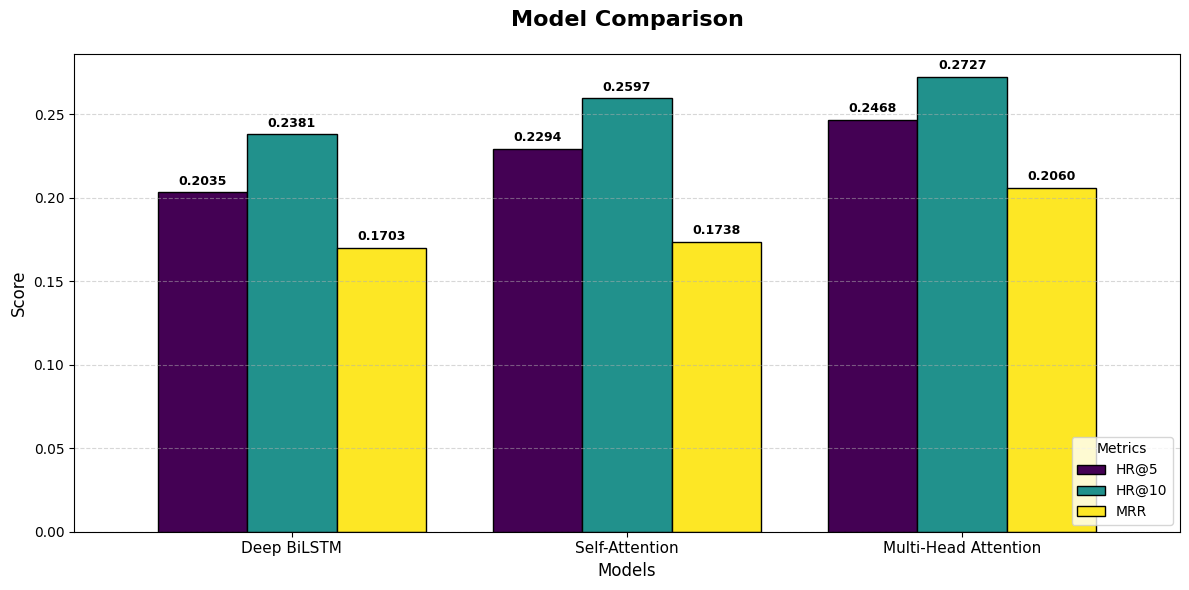


FINAL CONCLUSION (Based on Accuracy & Ranking):
1. For hit rate (HR@10): All ['Multi-Head Attention'] achieved the highest level (0.2727).
2. For ranking (MRR): 'Multi-Head Attention' clearly outperforms the others (0.2060).
   -> This means that MHA not only predicts correctly, but also ranks the correct item higher (Top 1–2).

📈 Improvement vs Self-Attention:
   - HR@10: +5.00%
   - MRR:   +18.54%

📈 Improvement vs Deep BiLSTM:
   - HR@10: +14.55%
   - MRR:   +20.97%

🏆 FINAL PICK: 'Multi-Head Attention' is the most optimal architecture.


In [45]:
df_results = pd.DataFrame(results).T 

desired_order = ['HR@5', 'HR@10', 'MRR']
cols_to_use = [c for c in desired_order if c in df_results.columns]
df_results = df_results[cols_to_use]

print("\n📊 Data Table:")
print("="*60)
print(df_results)
print("="*60)

ax = df_results.plot(kind='bar', figsize=(12, 6), width=0.8, colormap='viridis', edgecolor='black')

plt.title('Model Comparison', fontsize=16, fontweight='bold', pad=20)
plt.ylabel('Score', fontsize=12)
plt.xlabel('Models', fontsize=12)
plt.xticks(rotation=0, fontsize=11)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.legend(title='Metrics', loc='lower right', frameon=True)

for p in ax.patches:
    value = p.get_height()
    if value > 0: 
        ax.annotate(f'{value:.4f}', 
                    (p.get_x() + p.get_width() / 2., value), 
                    ha='center', va='center', 
                    xytext=(0, 8), 
                    textcoords='offset points',
                    fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()


best_model_hr = df_results['HR@10'].idxmax()
best_hr_val = df_results['HR@10'].max()

top_tier_models = df_results[df_results['HR@10'] >= best_hr_val - 0.0001].index

best_model_final = df_results.loc[top_tier_models, 'MRR'].idxmax()
best_mrr_val = df_results.loc[best_model_final, 'MRR']


second_best = 'Self-Attention'

mrr_improvement = (
    (best_mrr_val - df_results.loc[second_best, 'MRR']) 
    / df_results.loc[second_best, 'MRR']
) * 100

hr_improvement = (
    (best_hr_val - df_results.loc[second_best, 'HR@10']) 
    / df_results.loc[second_best, 'HR@10']
) * 100


baseline_bilstm = 'Deep BiLSTM'

mrr_improvement_bilstm = (
    (best_mrr_val - df_results.loc[baseline_bilstm, 'MRR'])
    / df_results.loc[baseline_bilstm, 'MRR']
) * 100

hr_improvement_bilstm = (
    (best_hr_val - df_results.loc[baseline_bilstm, 'HR@10'])
    / df_results.loc[baseline_bilstm, 'HR@10']
) * 100

print("\nFINAL CONCLUSION (Based on Accuracy & Ranking):")
print("="*60)
print(f"1. For hit rate (HR@10): All {top_tier_models.tolist()} achieved the highest level ({best_hr_val:.4f}).")
print(f"2. For ranking (MRR): '{best_model_final}' clearly outperforms the others ({best_mrr_val:.4f}).")
print(f"   -> This means that MHA not only predicts correctly, but also ranks the correct item higher (Top 1–2).")

print(f"\n📈 Improvement vs Self-Attention:")
print(f"   - HR@10: +{hr_improvement:.2f}%")
print(f"   - MRR:   +{mrr_improvement:.2f}%")

print(f"\n📈 Improvement vs Deep BiLSTM:")
print(f"   - HR@10: +{hr_improvement_bilstm:.2f}%")
print(f"   - MRR:   +{mrr_improvement_bilstm:.2f}%")

print(f"\n🏆 FINAL PICK: '{best_model_final}' is the most optimal architecture.")